In [1]:
import random 
import math
import matplotlib.pyplot as plt
import numpy as np
import json
from scipy.optimize import curve_fit
from joblib import Parallel, delayed

In [ ]:
loadingfile = "dados_5.txt"
with open(loadingfile, "r") as arquivo:
    d = json.load(arquivo)

N     = 400 
    
lista_L_D_steps = d["L_D_steps"]
lista_L_D_sig = d["L_D_sig"]
lista_n = d["n_exc"]

# Comprimento de difusão calculado pelo desvio padrão vs número de éxcitons

plt.figure()
plt.plot(lista_n, lista_L_D_sig, "o")
plt.ylabel(r"$L_D$ pelo desvio padrão")
plt.xlabel(r"Número de éxcitons")
plt.xlim(0,N+1)
plt.ylim(0,max(lista_L_D_sig)+1)
plt.show()

# Comprimento de difusão calculado pels passos vs número de éxcitons

plt.figure()
plt.plot(lista_n, lista_L_D_steps, "o")
plt.ylabel(r"$L_D$ pelo número de passos")
plt.xlabel(r"Número de éxcitons")
plt.xlim(0,N+1)
plt.ylim(0,max(lista_L_D_steps)+1)
plt.show()

# Comparação entre os comprimentos calculados 

plt.figure()
plt.plot(lista_L_D_sig, lista_L_D_steps, "o")
plt.ylabel(r"$L_D$ pelo número de passos")
plt.xlabel(r"$L_D$ pelo desvio padrão")
plt.xlim(0,max(lista_L_D_sig)+1)
plt.ylim(0,max(lista_L_D_steps)+1)
plt.show()


In [2]:
#%load_ext autoreload
#%autoreload 2
from importlib import reload
import KMC
reload(KMC)
import KMC


# Comprimento de difusão calculado pelos passos vs analítico (variando R_0)
# Valores altos de R_
loadingfile = "kappa.txt"
with open(loadingfile, "r") as arquivo:
    d = json.load(arquivo)

r    = 2      # distância entre as moléculas 
Tau  = 10#0.1

n = 10000  #número de éxcitons 
R_0 = np.linspace(2,4.0,10)

resultados = Parallel(n_jobs=10, verbose=10)(delayed(KMC.L_D_calc)(d,R_0[i],r,Tau,n) for i in range(len(R_0)))

L_D_sig   = np.array(resultados)[:,0]
L_D_steps = np.array(resultados)[:,1]

#print(resultados)
#print(L_D_sig)

lista_L_D_an = []
for i in range(len(R_0)):
    lista_L_D_an.append(KMC.L_D_an(R_0[i],r))

d = {"Sig_R0": L_D_sig.tolist(), "Steps_R0": L_D_steps.tolist(), "An_R0": lista_L_D_an}


with open("diffusion_dat.txt", "w") as arquivo:
    json.dump(d, arquivo)
arquivo.close()

[Parallel(n_jobs=10)]: Using backend LokyBackend with 10 concurrent workers.


2.3031283073246267 2.3094010767585034 2.614076341654926 2.6140763416549264
3.1797484177211253 3.1679027116028853 3.426066560941279 3.426066560941279
4.214546238920627 4.216478509143442 4.301251910781326 4.301251910781326


[Parallel(n_jobs=10)]: Done   3 out of  10 | elapsed:    1.6s remaining:    3.7s


5.524273707918535 5.474135885649784 5.787960773882284 5.787960773882284
7.032439121670375 6.9598822573915395 7.123822883817369 7.123822883817369


[Parallel(n_jobs=10)]: Done   5 out of  10 | elapsed:    3.2s remaining:    3.2s


8.751594140498062 8.692725040638317 8.702884321878582 8.702884321878582
10.660225138335495 10.691671651659737 10.75646326633434 10.75646326633434


[Parallel(n_jobs=10)]: Done   7 out of  10 | elapsed:    4.3s remaining:    1.8s


12.935315999232488 12.975729506725415 12.992812671627343 12.992812671627343
15.503599582032555 15.563906022104975 16.039559056283313 16.039559056283313
18.413853480464105 18.475208614068027 17.86481950426592 17.86481950426592


[Parallel(n_jobs=10)]: Done  10 out of  10 | elapsed:   10.1s finished


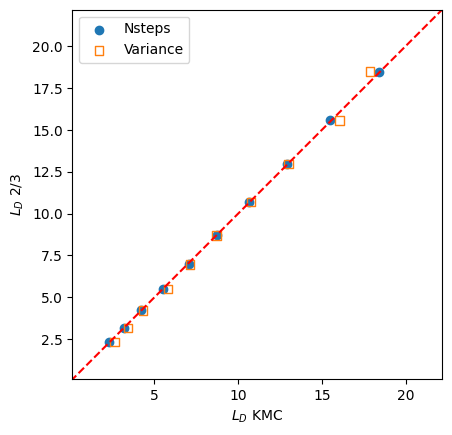

In [3]:
# Gráfico do comprimento analítico vs calculado pelo número de passos

with open("diffusion_dat.txt", "r") as arquivo:
    d1 = json.load(arquivo)

with open("dados_4.txt", "r") as arquivo:
    d = json.load(arquivo)     # Rede



L_D_steps = d1["Steps_R0"] #+ d2["Steps_R0"]
L_D_sig   = d1["Sig_R0"]
lista_L_D_an = d1["An_R0"] #+ d2["An_R0"]


plt.figure()
plt.scatter(np.array(L_D_steps), lista_L_D_an,label='Nsteps')
plt.scatter(np.array(L_D_sig), lista_L_D_an,label='Variance',facecolors='none', marker='s', edgecolors='#ff7f0e')
plt.xlabel(r"$L_D$ KMC")
plt.ylabel(r"$L_D$ 2/3")

f=1.2
L_D_max = max(L_D_steps + lista_L_D_an + L_D_sig)
plt.plot([0, f*L_D_max], [0, f*L_D_max], '--',c='r')
plt.xlim(0.1,f*L_D_max)
plt.ylim(0.1,f*L_D_max)
#plt.xscale("log")
#plt.yscale("log")
plt.legend()
plt.gca().set_box_aspect(1) #force square proportion. Better for pair plots
plt.show()


In [ ]:
# Comprimento de difusão calculado pelo desvio padrão vs analítico (variando R_0)

with open("dados_6.txt", "r") as arquivo:
    d = json.load(arquivo)

L_D_sig = d["Sig_R0"]
lista_L_D_an = d["An_R0"]

plt.figure()
plt.plot(L_D_sig, np.array(lista_L_D_an), "o")
plt.xlabel(r"$L_D$ KMC")
plt.ylabel(r"$L_D$ 2/3")
L_D_max = max(L_D_sig + lista_L_D_an)
plt.plot([0, L_D_max], [0, L_D_max], '--', label = 'Curva ideal')
plt.legend()
plt.show()
